In [62]:
import numpy as np
import scipy.linalg
from scipy.special import comb
from scipy.integrate import *

import matplotlib.pyplot as plt

from electron_integrals import *
from CI_physicist import *

Define functions

In [63]:
# Function to get reduced density matrices

def get_RDMs(num_orbitals, num_electrons, C):
    slater_dets = CIHamiltonian.get_slater_dets(num_orbitals, num_electrons)
    C_conj = C.conj()

    D = np.zeros((num_orbitals,)*2 , dtype=np.cdouble)
    d = np.zeros((num_orbitals,)*4, dtype=np.cdouble)

    for n, det_n in enumerate(slater_dets):
        for m, det_m in enumerate(slater_dets):
            num_differences = np.sum(np.abs(det_n-det_m))
            match(num_differences):
                case 0:
                    for p, n_p in enumerate(det_n):
                        D[p,p] += n_p*C_conj[m]*C[n]
                        for r, n_r in enumerate(det_n):
                            d[p,r,p,r] += n_p*n_r*C_conj[m]*C[n]
                            d[p,r,r,p] -= n_p*n_r*C_conj[m]*C[n] # Note the sign                 
                case 2:
                    p = np.flatnonzero(np.asarray((det_m-det_n)==1))[0]
                    q = np.flatnonzero(np.asarray((det_n-det_m)==1))[0]
                    gamma = (-1)**(np.sum(det_n[:q])+np.sum(det_m[:p]))
                    D[p,q] += gamma*C_conj[m]*C[n]

                    for r, n_r in enumerate(det_n):
                        val = gamma*n_r*C_conj[m]*C[n]
                        d[p,r,q,r] += val
                        d[r,p,q,r] -= val # Note the sign
                        d[p,r,r,q] -= val # Note the sign
                        d[r,p,r,q] += val

                case 4:
                    p,q = np.flatnonzero(np.asarray((det_m-det_n)==1))
                    r,s = np.flatnonzero(np.asarray((det_n-det_m)==1))
                    
                    gamma = np.sum(det_n[:r])
                    gamma += np.sum(det_n[:s])-1 # -1 since r<s 
                    gamma += np.sum(det_n[:q])-int(s<q)-int(r<q)
                    gamma += np.sum(det_n[:p])-int(s<p)-int(r<p) # No additional term since p<q

                    val = C_conj[m]*C[n]*(-1)**gamma
                    d[p,q,r,s] += val
                    d[q,p,r,s] -= val # Note the sign
                    d[p,q,s,r] -= val # Note the sign
                    d[q,p,s,r] += val

    return D, d


# Helper functions to put the problem on a form handled by standard SciPy ODE solvers 

def Cb_to_y(C, b):
    return np.concatenate([C.flatten(), b.flatten()])

def y_to_Cb(y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons):
    num_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))

    C, b = np.split(y, [num_slater_dets])
    b = b.reshape((num_spin_orbitals, num_mctdhf_orbitals))

    return C, b

Define number of electrons and orbitals

In [64]:
# Number of orbitals (without spin)
num_orbitals = 6
# Number of electrons
num_electrons = 1
#Include spin?
include_spin = False

spin_factor = 1+int(include_spin)

num_spin_orbitals = spin_factor*num_orbitals

Calculate electron integrals

In [65]:
def kinetic_energy_mels(i, j, dx):
    with np.errstate(divide='ignore'):
        return np.where(
            i==j,
            np.pi ** 2 / (6 * dx ** 2),
            (-1.0) ** (i_min_j := i - j) / (dx ** 2 * i_min_j **2),
        )

In [66]:
grid = np.linspace(-4, 4, num_orbitals)
dx = np.abs(grid[1] - grid[0])
inds=np.arange(len(grid))

potential = lambda x, omega=1: 0.5 * omega**2 * x ** 2

t = kinetic_energy_mels(inds[:, None], inds[None, :], dx)

h = t + np.diag(potential(grid))

g = shielded_coulomb(grid[:, None], grid[None, :], kappa=1, a=0.01)*0


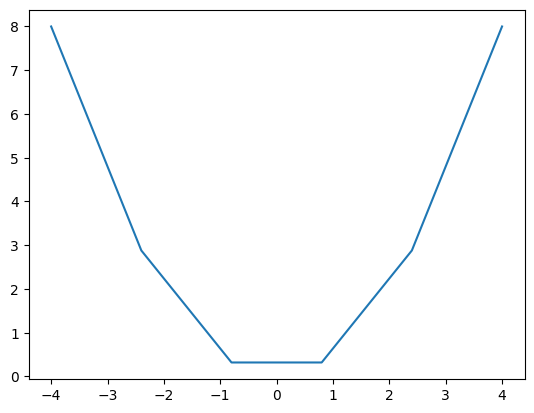

In [67]:
plt.plot(grid,potential(grid))
plt.show()

# Orbital equations

Define number of MCTDHF orbitals $(\{\ket{\phi_n(t)}\})$, initial b's (basis reduction coefficients),

$\ket{\phi_n(t)} = \sum_{k=1}^{N_b}b_{kn}(t)\ket{\psi_k}$,

and initial C's.


In [68]:
num_mctdhf_orbitals = 4
num_mctdhf_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))

## Distributed vales
#b_init = np.zeros((num_spin_orbitals, num_mctdhf_orbitals))
#a = int(num_spin_orbitals/num_mctdhf_orbitals)
#for i in range(num_mctdhf_orbitals):
#    b_init[a*i:a*(i+1), i] = np.ones(a)

## Identity
#b_init=np.eye(num_spin_orbitals, num_mctdhf_orbitals)

## Generate random orthonormal vectors
rng = np.random.default_rng()
r = rng.random((num_spin_orbitals, num_mctdhf_orbitals))
u, _, vh = np.linalg.svd(r, full_matrices=False)
b_init = (u@vh).astype(np.cdouble)*3

print(b_init)

# Ones as initial C
#C_init = np.ones((num_mctdhf_slater_dets), dtype=np.cdouble)

# Random initial C
#C_init = rng.random(num_mctdhf_slater_dets).astype(np.cdouble)

#Normalize
#C_init = np.divide(C_init, np.sqrt(C_init.T.conj()@C_init))

# One element
C_init=np.zeros(num_mctdhf_slater_dets)
C_init[0]=1

print(C_init)

[[ 0.38060333+0.j  0.29562563+0.j  1.18736756+0.j -0.81776186+0.j]
 [ 0.22790474+0.j  1.82779252+0.j -1.32161395+0.j  1.7087059 +0.j]
 [-0.18360905+0.j  0.71917207+0.j  1.86272056+0.j  0.65534268+0.j]
 [ 2.13359788+0.j  1.07108545+0.j -0.47299599+0.j -1.52723027+0.j]
 [ 0.3742653 +0.j  1.22079396+0.j  1.42875248+0.j  0.54633357+0.j]
 [ 2.01920128+0.j -1.55467347+0.j  0.32970916+0.j  1.5333633 +0.j]]
[1. 0. 0. 0.]


Define callable class for the differential equations

In [69]:
class MCDTHF_imaginary_time:
    def __init__(self, h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons):
        self.h = h
        self.g = g
        self.num_mctdhf_orbitals = num_mctdhf_orbitals
        self.num_spin_orbitals = num_spin_orbitals
        self.num_electrons = num_electrons
        

    def __call__(self, t, y):
        
        C, b = y_to_Cb(y, self.num_mctdhf_orbitals, self.num_spin_orbitals, self.num_electrons)

        #C = np.divide(C, np.sqrt(C.T.conj()@C))
        #b = np.divide(b, np.sqrt(np.einsum('ij, ij -> j', b.conj(), b)))


        bc = b.conj()

        h_1 = np.einsum('jm, ij -> im', b, self.h)
        h_2 = np.einsum('in, im -> nm', bc, h_1) # Fully transformed integral
        h_3 = np.einsum('in, nm -> im', b, h_2)

        # g_ijkl = delta_ij delta_kl g_ik  
        g_2 = np.einsum('iq, ks, ik -> iqks', bc, b, self.g)
        g_3 = np.einsum('kr, iqks -> iqrs', b, g_2)
        g_4 = np.einsum('ip, iqrs -> pqrs', bc, g_3) # Fully transformed integral
        g_5 = np.einsum('ip, pqrs -> iqrs', b, g_4)

        D, d = get_RDMs(num_mctdhf_orbitals, num_electrons, C)
        
        H = SlaterCondonHamiltonian(self.num_mctdhf_orbitals, self.num_electrons, h_2, g_4).get_hamiltonian()

        ## From Beck paper, replacing HC with (H-IE)C should keep the wave function normalized (should be able to remove renormalization further down)
        E = C.conj().T@H@C/(C.conj().T@C)
        num_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))
        C_dot = - (H-np.eye(num_slater_dets)*E)@C
        #C_dot = -np.matmul(H,C)
        C_dot = np.zeros_like(C)

        b_dot = -(h_1-h_3) #+ np.einsum('np, pqrs, kqrs -> kn', np.linalg.pinv(D), d, g_3-g_5)
        #b_dot = gram_schmidt(b_dot)

        return Cb_to_y(C_dot, b_dot)

Solve using ODE solver

In [70]:
#mctdhf_fun = MCDTHF(h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
mctdhf_fun = MCDTHF_imaginary_time(h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)

y_init = Cb_to_y(C_init, b_init)

Cs = np.copy(C_init).reshape(1,-1)
bs = np.copy(b_init).reshape(1,-1)

h_1 = np.einsum('jm, ij -> im', b_init, h)
h_2 = np.einsum('in, im -> nm', b_init.conj(), h_1)

g_2 = np.einsum('iq, ks, ik -> iqks', b_init.conj(), b_init, g)
g_3 = np.einsum('kr, iqks -> iqrs', b_init, g_2)
g_4 = np.einsum('ip, iqrs -> pqrs', b_init.conj(), g_3) # Fully transformed integral

H = SlaterCondonHamiltonian(num_mctdhf_orbitals, num_electrons, h_2, g_4).get_hamiltonian()
Es = np.array(np.real(C_init.T@H@C_init))

t_init = 0
t_final = 10.0
#solver = DOP853(mctdhf_fun, t_init, y_init, t_final)
solver = RK45(mctdhf_fun, t_init, y_init, t_final)

while solver.status == 'running':
    msg = solver.step()

    C, b = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)

    #if solver.nfev % 100 == 0:
    ## Transform with overlap
    S = dx*np.einsum('ip, iq -> pq', b.conj(), b) #b.conj().T@b
    _, S_tilde = np.linalg.eigh(S)
    b = np.einsum('ip, qp -> iq', b, S_tilde)
    # Or transform with orth (SVD)
        #b = scipy.linalg.orth(b)

    #b = gram_schmidt(b)

    # Normalize every step during imaginary time prop
    C = np.divide(C, np.sqrt(C.T.conj()@C))
    b = np.divide(b, np.sqrt(dx*np.einsum('ij, ij -> j', b.conj(), b)))

    h_1 = np.einsum('jm, ij -> im', b, h)
    h_2 = np.einsum('in, im -> nm', b.conj(), h_1)

    g_2 = np.einsum('iq, ks, ik -> iqks', b.conj(), b, g)
    g_3 = np.einsum('kr, iqks -> iqrs', b, g_2)
    g_4 = np.einsum('ip, iqrs -> pqrs', b.conj(), g_3) # Fully transformed integral

    H = SlaterCondonHamiltonian(num_mctdhf_orbitals, num_electrons, h_2, g_4).get_hamiltonian()

    Es = np.append(Es, np.real(C.conj().T@H@C))
    Cs = np.append(Cs, C.reshape(1,-1), axis=0)
    bs = np.append(bs, b.reshape(1,-1), axis=0)

    solver.y = Cb_to_y(C, b)
else:
    if solver.status != 'finished':
        raise(RuntimeError(msg))

In [71]:
#print(f'Original value:\n {b}')
#print(f'scipy.orth:\n {scipy.linalg.orth(b)}')
S = dx*np.einsum('ip, iq -> pq', b.conj(), b) #b.conj().T@b
_, S_tilde = np.linalg.eigh(S)
#print(f"Overlap matrix:\n{np.einsum('ip, qp -> iq', b, S_tilde)}")
print(S)
np.linalg.norm(S[:,0])

[[ 1.        +0.j -0.00353671+0.j -0.07094293+0.j -0.00517631+0.j]
 [-0.00353671+0.j  1.        +0.j -0.00336721+0.j -0.06786301+0.j]
 [-0.07094293+0.j -0.00336721+0.j  1.        +0.j  0.00864432+0.j]
 [-0.00517631+0.j -0.06786301+0.j  0.00864432+0.j  1.        +0.j]]


1.0025328930060868

In [72]:
print(b)

[[-0.02773603+0.j -0.04781067+0.j -0.00425009+0.j -0.02559688+0.j]
 [-0.29462013+0.j -0.57483525+0.j -0.24362825+0.j -0.32315583+0.j]
 [ 0.27129345+0.j  0.32492849+0.j -0.61371216+0.j -0.3296058 +0.j]
 [ 0.3871231 +0.j -0.0538221 +0.j  0.39430814+0.j -0.53555407+0.j]
 [ 0.55886374+0.j -0.42792107+0.j -0.18146287+0.j  0.35098123+0.j]
 [ 0.04045473+0.j -0.02620672+0.j -0.02401897+0.j  0.03562502+0.j]]


In [73]:
def gram_schmidt(b):
    b = np.divide(b, np.sqrt(np.einsum('ij, ij -> j', b.conj(), b)))
    for i in range(b.shape[1]):

        orto_adjustment = 0
        for j in range(0, i):
            orto_adjustment += np.dot(b[:, i], b[:, j])*b[:, j]

        b[:,i] -= orto_adjustment

    return b

b_pert = np.zeros_like(b)
b_pert[:,-1] = 0.1*b[:,0]

#print(b)
print(gram_schmidt(b))#+b_pert))
#print(scipy.linalg.orth(b))
Q, R = scipy.linalg.qr(b.T, mode='economic')
print(Q.T)
#print(b.T@R.T)

[[-0.03508361+0.j -0.06060033+0.j -0.00808418+0.j -0.03660808+0.j]
 [-0.37266826+0.j -0.72843349+0.j -0.33724181+0.j -0.4574309 +0.j]
 [ 0.34316208+0.j  0.41221931+0.j -0.75045493+0.j -0.38113644+0.j]
 [ 0.4896763 +0.j -0.06634832+0.j  0.53326374+0.j -0.68368027+0.j]
 [ 0.70691292+0.j -0.53878195+0.j -0.18133329+0.j  0.41250239+0.j]
 [ 0.05117164+0.j -0.03296819+0.j -0.02687087+0.j  0.04330525+0.j]]
[[-0.45423686+0.j -0.78300213+0.j -0.06960429+0.j -0.41920375+0.j]
 [ 0.20232052+0.j  0.00877443+0.j -0.9765196 +0.j -0.0734771 +0.j]
 [ 0.10965246+0.j  0.41012884+0.j  0.09416082+0.j -0.90050231+0.j]
 [-0.86064605+0.j  0.46757353+0.j -0.18082713+0.j  0.08924641+0.j]]


In [74]:
def normalize(v):
    return v / np.sqrt(v.dot(v))

n = len(b)

b2 = np.copy(b)
b2[:, 0] = normalize(b2[:, 0])

for i in range(1, n):
    Ai = b2[:, i]
    for j in range(0, i):
        Aj = b2[:, j]
        t = Ai.dot(Aj)
        Ai = Ai - t * Aj
    b2[:, i] = normalize(Ai)

IndexError: index 4 is out of bounds for axis 1 with size 4

In [ ]:
print(b2)

[[-0.49196381+0.j  0.17615691+0.j  0.85260797+0.j  0.21550358+0.j]
 [-0.23193806+0.j -0.97044298+0.j  0.06667203+0.j  0.44841578+0.j]
 [ 0.83915216+0.j -0.16495201+0.j  0.51828032+0.j -0.04981461+0.j]]


In [ ]:
def qr_factorization(A):
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))

    for j in range(n):
        v = A[:, j]

        for i in range(j - 1):
            q = Q[:, i]
            R[i, j] = q.dot(v)
            v = v - R[i, j] * q

        norm = np.linalg.norm(v)
        Q[:, j] = v / norm
        R[j, j] = norm
    return Q, R

Q, R = qr_factorization(b)

print(Q)

[[-0.49196381  0.31805399  0.85198553  0.94217614]
 [-0.23193806 -0.85316131 -0.32658778  0.33299779]
 [ 0.83915216 -0.41347001  0.40922008  0.03763766]]


/tmp/ipykernel_202704/2112365497.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  Q[:, j] = v / norm
/tmp/ipykernel_202704/2112365497.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  R[i, j] = q.dot(v)


[[ 0.0078267 +0.j  0.00234194+0.j -0.00344379+0.j  0.00520176+0.j]
 [ 0.01882545+0.j  0.00574721+0.j -0.00847036+0.j  0.01263459+0.j]
 [ 0.03328855+0.j  0.01050215+0.j -0.01552679+0.j  0.02269957+0.j]
 [ 0.05332639+0.j  0.01756713+0.j -0.02604602+0.j  0.03712089+0.j]
 [ 0.08034725+0.j  0.02790982+0.j -0.04145369+0.j  0.05733758+0.j]
 [ 0.11555413+0.j  0.04273934+0.j -0.06347217+0.j  0.08487316+0.j]
 [ 0.15905933+0.j  0.06332734+0.j -0.09379677+0.j  0.12076274+0.j]
 [ 0.20960288+0.j  0.09097684+0.j -0.13394978+0.j  0.16531035+0.j]
 [ 0.26380203+0.j  0.1267859 +0.j -0.18481013+0.j  0.21744189+0.j]
 [ 0.31595234+0.j  0.17146321+0.j -0.24619942+0.j  0.27429004+0.j]
 [ 0.35798213+0.j  0.22503883+0.j -0.31634512+0.j  0.33075171+0.j]
 [ 0.38025973+0.j  0.28665575+0.j -0.39153707+0.j  0.37950484+0.j]
 [ 0.3729717 +0.j  0.35437786+0.j -0.4659713 +0.j  0.41139798+0.j]
 [ 0.32832863+0.j  0.42516108+0.j -0.53205204+0.j  0.41651638+0.j]
 [ 0.24299696+0.j  0.49494103+0.j -0.58114295+0.j  0.38572086+

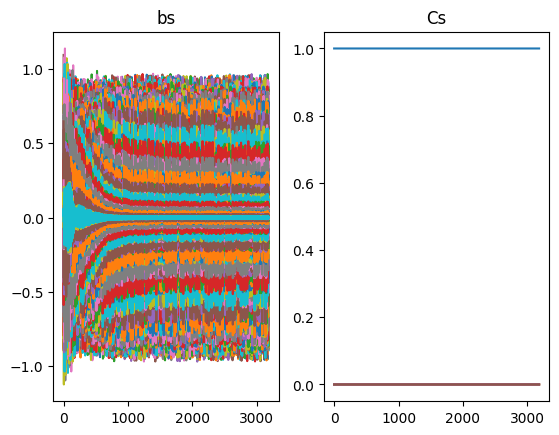

In [ ]:
C_f, b_f = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
S_f = np.einsum('ip, iq -> pq', b_f.conj(), b_f)

b_f = b_f.reshape((num_spin_orbitals, num_mctdhf_orbitals))
print(b_f)

#plt.plot(grid, np.abs(b_f[:,3])**2)

# print(S_f)
# print(S_f.T@S_f)
fig, axs = plt.subplots(1,2)

axs[0].plot(np.real(bs))
axs[0].set_title('bs')

axs[1].plot(np.real(Cs))
axs[1].set_title('Cs')

plt.show()

22.040419784677397


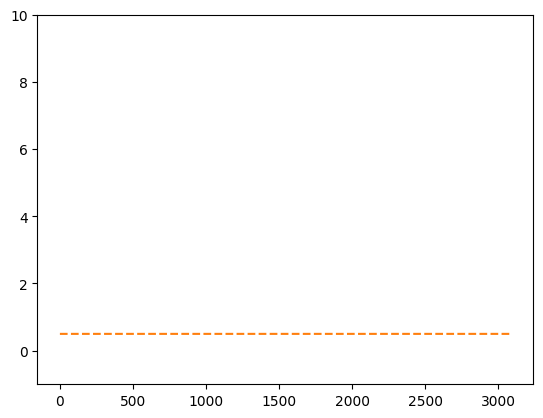

In [ ]:
print(Es[-1])
plt.plot(Es)
plt.plot(0.5*np.ones_like(Es), '--')
plt.ylim([-1,10])
plt.show()